# Hybrid XGBoost + Neural Network — Wearable CVD Risk Prediction

This notebook trains a **stacked hybrid model** for predicting daily physician-review alerts from wearable data.

**Dataset:** `wearable_cvd_synthetic_dataset.xlsx` (150 participants × 30 days).

### Architecture

```
              ┌────────────────────────┐
  past-7-day  │   1D-CNN encoder       │     embedding
  vitals  ──► │   (PyTorch)            │ ──► (4-d)    ─┐
  (7×9)       └────────────────────────┘               │
                                                       ▼
  statics + current-day + 7-d rolling ────► concat ──► XGBoost ──► P(alert)
```

- **Target:** `physician_review_alert` (binary, ~3% positive prevalence)
- **Split:** participant-level (prevents same-person leakage across train/test)



## 1. Imports

In [17]:
! git clone https://github.com/georggr/KI-CVD-Risk-Predictor.git

fatal: destination path 'KI-CVD-Risk-Predictor' already exists and is not an empty directory.


In [18]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
from sklearn.metrics import (average_precision_score, classification_report,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=UserWarning)

## 2. Configuration

Adjust `DATA_PATH` to point at your local copy of the dataset. The other knobs control the CNN training loop and the sequence-window length.

In [19]:
DATA_PATH = Path("KI-CVD-Risk-Predictor/wearable_cvd_synthetic_dataset.xlsx")
SEQ_LEN = 7          # days of history fed to the CNN
EMBED_DIM = 4        # small embedding → summarises, doesn't crowd out tabular signal
NN_EPOCHS = 60       # upper bound; early stopping decides actual epoch count
NN_PATIENCE = 8
NN_BATCH = 128
NN_LR = 1e-3
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 3. Load and merge the source sheets

The final grain is one row per `(participant_id, date)`, so each daily wearable record is enriched with:

- daily risk-engineered features from the `Daily_Risk_Scores` sheet, and
- static participant metadata from the `Participants` sheet.

In [20]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load and merge all source sheets into one modeling table."""
    sheets = pd.read_excel(path, sheet_name=["Participants",
                                             "Daily_Wearable_Data",
                                             "Daily_Risk_Scores"])
    participants = sheets["Participants"]
    daily = sheets["Daily_Wearable_Data"]
    risk = sheets["Daily_Risk_Scores"]

    df = (daily
          .merge(risk, on=["participant_id", "date"], how="inner")
          .merge(participants, on="participant_id", how="left")
          .sort_values(["participant_id", "date"])
          .reset_index(drop=True))
    return df


print("Loading dataset…")
df = load_dataset(DATA_PATH)
print(f"  merged rows: {len(df):,}   participants: {df['participant_id'].nunique()}")
df.head()

Loading dataset…
  merged rows: 4,500   participants: 150


,participant_id,date,day_of_week,device_worn_hours,step_count,active_minutes,resting_hr_bpm,mean_hr_bpm,max_hr_bpm,hrv_sdnn_ms,...,osa_dx,family_history_cvd,total_cholesterol_mgdl,hdl_mgdl,skin_tone_fitzpatrick,lifestyle_profile,occupation_category,device_model,wrist_worn,enrollment_date
0,P0001,2026-04-26,Sun,22.3,11943,98,68.1,104.4,136.8,21.4,...,0,0,197,47,IV,moderate,manual_labor,Fitbit Charge 6,right,2026-04-21
1,P0001,2026-04-27,Mon,23.4,12484,97,68.8,97.6,109.6,27.8,...,0,0,197,47,IV,moderate,manual_labor,Fitbit Charge 6,right,2026-04-21
2,P0001,2026-04-28,Tue,22.5,12667,86,67.9,106.2,157.3,39.0,...,0,0,197,47,IV,moderate,manual_labor,Fitbit Charge 6,right,2026-04-21
3,P0001,2026-04-29,Wed,21.3,11284,95,66.7,101.1,104.4,50.9,...,0,0,197,47,IV,moderate,manual_labor,Fitbit Charge 6,right,2026-04-21
4,P0001,2026-04-30,Thu,15.6,14877,117,63.5,103.9,136.4,34.6,...,0,0,197,47,IV,moderate,manual_labor,Fitbit Charge 6,right,2026-04-21


Quick look at the target prevalence — this is a heavily imbalanced binary problem, which we'll handle with `scale_pos_weight` later.

In [21]:
y = df["physician_review_alert"].to_numpy(dtype=np.float32)
print(f"positive class prevalence: {y.mean():.2%}")
print(f"positives: {int(y.sum())}   negatives: {int((y == 0).sum())}")

positive class prevalence: 3.11%
positives: 140   negatives: 4360


## 4. Feature engineering

Three feature blocks:

1. **Sequence channels** — fed to the 1D-CNN as multivariate daily time series.
2. **Categorical statics** — one-hot encoded for the tabular block.
3. **Numeric tabular** — statics + same-day vitals + 7-day rolling stats.

In [22]:
# Channels fed into the 1D-CNN — multivariate daily time series.
SEQ_CHANNELS = ["resting_hr_bpm", "mean_hr_bpm", "max_hr_bpm",
                "hrv_sdnn_ms", "sleep_duration_h", "sleep_efficiency_pct",
                "spo2_nocturnal_min_pct", "odi3_events_per_hour", "step_count"]

# Categorical statics — one-hot encoded for the tabular block.
CAT_COLS = ["sex", "smoking_status", "skin_tone_fitzpatrick",
            "lifestyle_profile", "occupation_category", "device_model"]

# Numeric tabular features (statics + same-day vitals + 7-day rolling stats).
NUM_COLS = [
    # statics
    "age_years", "altitude_residence_m", "bmi",
    "hypertension_dx", "diabetes_dx", "osa_dx", "family_history_cvd",
    "total_cholesterol_mgdl", "hdl_mgdl",
    # same-day wearable
    "device_worn_hours", "step_count", "active_minutes",
    "resting_hr_bpm", "mean_hr_bpm", "max_hr_bpm", "hrv_sdnn_ms",
    "sleep_duration_h", "sleep_efficiency_pct",
    "spo2_mean_pct", "spo2_nocturnal_min_pct", "odi3_events_per_hour",
    "vo2_max_estimate", "ppg_signal_quality_pct",
    # 7-day rolling (already in Daily_Risk_Scores)
    "roll7_resting_hr", "roll7_hrv_sdnn", "roll7_steps",
    "roll7_sleep_h", "roll7_spo2_nadir", "roll7_odi",
]

print(f"sequence channels: {len(SEQ_CHANNELS)}")
print(f"categorical cols : {len(CAT_COLS)}")
print(f"numeric cols     : {len(NUM_COLS)}")

sequence channels: 9
categorical cols : 6
numeric cols     : 29


### 4a. Build the sequence tensor

For each row, gather the previous `SEQ_LEN` days of `SEQ_CHANNELS` for the same participant. Days that fall off the start of the window are forward-filled from the earliest available day — this preserves causality and avoids look-ahead leakage. Output shape: `(n_rows, seq_len, n_channels)`.

In [23]:
def build_sequence_tensor(df: pd.DataFrame, seq_len: int = SEQ_LEN) -> np.ndarray:
    """Build per-row trailing windows of SEQ_CHANNELS, participant by participant."""
    n_rows = len(df)
    n_ch = len(SEQ_CHANNELS)
    seqs = np.zeros((n_rows, seq_len, n_ch), dtype=np.float32)

    # Build windows participant-by-participant so no history ever crosses users.
    for _, group in df.groupby("participant_id", sort=False):
        idx = group.index.to_numpy()
        vals = group[SEQ_CHANNELS].to_numpy(dtype=np.float32)
        for i in range(len(idx)):
            # Inclusive trailing window ending at day i.
            start = max(0, i - seq_len + 1)
            window = vals[start:i + 1]
            if len(window) < seq_len:                  # pad at the front
                pad = np.repeat(window[:1], seq_len - len(window), axis=0)
                window = np.vstack([pad, window])
            seqs[idx[i]] = window
    return seqs

### 4b. Build the tabular block

One-hot encode categoricals, keep numerics as-is, then median-impute any remaining NaNs.

In [24]:
def build_tabular(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Build the non-sequential feature block used by XGBoost."""
    cat = pd.get_dummies(df[CAT_COLS].astype(str), drop_first=False)
    num = df[NUM_COLS].copy()
    X = pd.concat([num, cat], axis=1)
    X = X.fillna(X.median(numeric_only=True))
    return X, list(X.columns)

### 4c. Run feature construction

In [25]:
print("Building features…")

# Impute NaN in sequence channels (e.g. SpO2 on devices that don't support it)
# using each channel's median computed on the full table.
df[SEQ_CHANNELS] = df[SEQ_CHANNELS].fillna(df[SEQ_CHANNELS].median(numeric_only=True))

X_tab_df, tab_cols = build_tabular(df)
X_tab = X_tab_df.to_numpy(dtype=np.float32)
X_seq = build_sequence_tensor(df)

print(f"  tabular   : {X_tab.shape}")
print(f"  sequences : {X_seq.shape}")
print(f"  tab cols  : {len(tab_cols)}")

Building features…
  tabular   : (4500, 62)
  sequences : (4500, 7, 9)
  tab cols  : 62


## 5. Participant-level train/test split

This is stricter and more realistic than row-level random splits — no person appears in both train and test, so the model can't memorise per-person quirks.

In [26]:
participants = df["participant_id"].unique()
train_p, test_p = train_test_split(participants, test_size=0.25,
                                   random_state=RANDOM_STATE)
train_idx = np.where(df["participant_id"].isin(train_p))[0]
test_idx = np.where(df["participant_id"].isin(test_p))[0]

print(f"  train participants: {len(train_p)}   test participants: {len(test_p)}")
print(f"  train rows: {len(train_idx)}        test rows: {len(test_idx)}")

  train participants: 112   test participants: 38
  train rows: 3360        test rows: 1140


### 5a. Scale features using training-only stats

In [27]:
# Standardise sequence channels using training-only stats (no leakage).
flat_train = X_seq[train_idx].reshape(-1, X_seq.shape[-1])
seq_mean = flat_train.mean(axis=0)
seq_std = flat_train.std(axis=0) + 1e-6
X_seq = (X_seq - seq_mean) / seq_std

# Scale tabular features.
# XGBoost itself is mostly scale-invariant, but scaling keeps feature ranges
# comparable and is useful if this matrix is reused in linear/NN baselines.
scaler = StandardScaler().fit(X_tab[train_idx])
X_tab_s = scaler.transform(X_tab)

# Positive-class weighting: negatives / positives in training split.
pos_weight = (y[train_idx] == 0).sum() / max(1, (y[train_idx] == 1).sum())
print(f"scale_pos_weight = {pos_weight:.1f}")

scale_pos_weight = 31.9


## 6. Neural network: 1D-CNN encoder + classification head

Small 1D-CNN: takes `(B, n_channels, seq_len)` → embedding `(B, EMBED_DIM)`.

A linear classification head sits on top of the embedding during training. Once trained we **drop the head** and use the embedding as features for XGBoost.

In [28]:
class SequenceEncoder(nn.Module):
    """
    Small 1D-CNN: takes (B, n_channels, seq_len) → embedding (B, EMBED_DIM).
    A linear classification head sits on top of the embedding during training;
    once trained we drop the head and use the embedding as features for XGBoost.
    """
    def __init__(self, n_channels: int, seq_len: int, embed_dim: int = EMBED_DIM):
        super().__init__()
        # Two light temporal convolutions capture short local dynamics
        # (sleep/HR/SpO2 variability patterns) over the 7-day context.
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                   # → (B, 32, 1)
        )
        # Small embedding acts as a compact summary for stacking with tabular data.
        self.embed = nn.Linear(32, embed_dim)
        # Binary head is only used while training the encoder.
        self.head = nn.Linear(embed_dim, 1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.conv(x).squeeze(-1)                   # (B, 32)
        return torch.relu(self.embed(h))               # (B, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encode(x)).squeeze(-1)   # logits

### 6a. CNN training loop with early stopping

End-to-end training on the alert target, with early stopping on a **participant-disjoint validation slice** carved out of the training set.

In [29]:
def train_nn(X_seq: np.ndarray, y: np.ndarray, train_idx: np.ndarray,
             pos_weight: float, participants: np.ndarray) -> SequenceEncoder:
    """End-to-end CNN training with participant-disjoint validation slice."""
    # Carve a participant-level validation slice (~20% of train participants).
    train_p = np.unique(participants[train_idx])
    rng = np.random.default_rng(RANDOM_STATE)
    rng.shuffle(train_p)
    val_p = set(train_p[:max(1, len(train_p) // 5)])
    val_mask = np.isin(participants[train_idx], list(val_p))
    tr_sub_idx = train_idx[~val_mask]
    val_sub_idx = train_idx[val_mask]

    def make_loader(idx, shuffle):
        # PyTorch Conv1d expects channels-first tensors: (batch, channels, seq_len).
        xt = torch.from_numpy(X_seq[idx]).permute(0, 2, 1)
        yt = torch.from_numpy(y[idx]).float()
        return DataLoader(TensorDataset(xt, yt), batch_size=NN_BATCH, shuffle=shuffle)

    train_loader = make_loader(tr_sub_idx, shuffle=True)
    val_loader = make_loader(val_sub_idx, shuffle=False)

    model = SequenceEncoder(n_channels=len(SEQ_CHANNELS), seq_len=SEQ_LEN)
    opt = torch.optim.Adam(model.parameters(), lr=NN_LR)
    # Weigh positives more heavily to counter the low alert prevalence.
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))

    best_val = float("inf")
    best_state = None
    stale = 0
    for epoch in range(NN_EPOCHS):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            # BCEWithLogitsLoss combines sigmoid + BCE in one numerically stable op.
            loss_fn(model(xb), yb).backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = sum(loss_fn(model(xb), yb).item() * xb.size(0)
                           for xb, yb in val_loader) / len(val_sub_idx)
        if val_loss < best_val - 1e-4:
            best_val, best_state, stale = val_loss, {k: v.clone()
                                                     for k, v in model.state_dict().items()}, 0
        else:
            stale += 1
        if (epoch + 1) % 10 == 0 or stale == 0:
            print(f"  epoch {epoch+1:2d}  val_loss={val_loss:.4f}"
                  f"{'  ✓ best' if stale == 0 else ''}")
        if stale >= NN_PATIENCE:
            print(f"  early stop at epoch {epoch+1}")
            break

    # Restore best validation epoch before returning encoder.
    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def extract_embeddings(model: SequenceEncoder, X_seq: np.ndarray) -> np.ndarray:
    """Transform every sequence window into learned dense features."""
    model.eval()
    xt = torch.from_numpy(X_seq).permute(0, 2, 1)
    emb = model.encode(xt).cpu().numpy()
    return emb

## 7. Train the CNN sequence encoder

In [30]:
print("Training 1D-CNN sequence encoder…")
participants_arr = df["participant_id"].to_numpy()
nn_model = train_nn(X_seq, y, train_idx,
                    pos_weight=pos_weight, participants=participants_arr)

Training 1D-CNN sequence encoder…
  epoch  1  val_loss=1.7681  ✓ best
  epoch  2  val_loss=1.5990  ✓ best
  epoch 10  val_loss=4.0671
  early stop at epoch 10


### 7a. Extract learned embeddings for every row

In [31]:
print("Extracting learned embeddings…")
emb = extract_embeddings(nn_model, X_seq)
print(f"  embedding matrix: {emb.shape}")

Extracting learned embeddings…
  embedding matrix: (4500, 4)


## 8. Evaluation helper

Reports both **ranking quality** (ROC-AUC, PR-AUC — important on imbalanced data) and **thresholded classification** metrics at the default 0.5 cutoff.

In [32]:
def report(name: str, y_true: np.ndarray, p: np.ndarray) -> dict:
    auc = roc_auc_score(y_true, p)
    ap = average_precision_score(y_true, p)
    print(f"\n── {name} ──")
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  PR-AUC  : {ap:.4f}")
    print(classification_report(y_true, (p >= 0.5).astype(int),
                                digits=3, zero_division=0))
    return {"name": name, "roc_auc": auc, "pr_auc": ap}

## 9. Train the four models

### 9a. Baseline A — XGBoost on tabular features only

A strong non-neural benchmark for mixed clinical / wearable data.

In [33]:
print("Training baseline XGBoost (tabular only)…")
xgb_base = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
)
xgb_base.fit(X_tab[train_idx], y[train_idx],
             eval_set=[(X_tab[test_idx], y[test_idx])], verbose=False)
p_base = xgb_base.predict_proba(X_tab[test_idx])[:, 1]
print(f"  predictions: {p_base.shape}")

Training baseline XGBoost (tabular only)…
  predictions: (1140,)


### 9b. Baseline B — NN-only logits

Measures what sequence dynamics alone can explain.

In [34]:
with torch.no_grad():
    nn_model.eval()
    logits = nn_model(torch.from_numpy(X_seq[test_idx]).permute(0, 2, 1))
    p_nn = torch.sigmoid(logits).cpu().numpy()
print(f"  predictions: {p_nn.shape}")

  predictions: (1140,)


### 9c. Hybrid 1 — stacked XGBoost on `[tabular ∪ NN embeddings]`

Combines handcrafted tabular predictors with learned sequence summaries in one tree model.

In [35]:
print("Training hybrid XGBoost (tabular + NN embeddings)…")
X_hyb = np.hstack([X_tab, emb])
xgb_hyb = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=pos_weight, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
)
xgb_hyb.fit(X_hyb[train_idx], y[train_idx],
            eval_set=[(X_hyb[test_idx], y[test_idx])], verbose=False)
p_hyb = xgb_hyb.predict_proba(X_hyb[test_idx])[:, 1]
print(f"  hybrid feature matrix: {X_hyb.shape}")
print(f"  predictions: {p_hyb.shape}")

Training hybrid XGBoost (tabular + NN embeddings)…
  hybrid feature matrix: (4500, 66)
  predictions: (1140,)


### 9d. Hybrid 2 — probability ensemble (geometric mean of NN and XGB)

Often more robust than stacking on small / noisy data because each branch keeps its own inductive bias.

In [36]:
p_ens = np.sqrt(np.clip(p_base, 1e-6, 1) * np.clip(p_nn, 1e-6, 1))
print(f"  predictions: {p_ens.shape}")

  predictions: (1140,)


## 10. Results on held-out participants

In [37]:
print("=" * 60)
print("RESULTS (held-out participants)")
print("=" * 60)
rows = [
    report("Neural net only (1D-CNN)", y[test_idx], p_nn),
    report("XGBoost only (tabular)", y[test_idx], p_base),
    report("Hybrid 1: stacked (XGB on tabular + NN emb)", y[test_idx], p_hyb),
    report("Hybrid 2: probability ensemble (NN × XGB)", y[test_idx], p_ens),
]

print("\nSummary")
print("-" * 60)
print(f"{'model':50s} {'ROC-AUC':>9s} {'PR-AUC':>9s}")
for r in rows:
    print(f"{r['name']:50s} {r['roc_auc']:>9.4f} {r['pr_auc']:>9.4f}")

RESULTS (held-out participants)

── Neural net only (1D-CNN) ──
  ROC-AUC : 0.8961
  PR-AUC  : 0.8129
              precision    recall  f1-score   support

         0.0      0.992     0.764     0.863      1102
         1.0      0.107     0.816     0.188        38

    accuracy                          0.766      1140
   macro avg      0.549     0.790     0.526      1140
weighted avg      0.962     0.766     0.841      1140


── XGBoost only (tabular) ──
  ROC-AUC : 0.9387
  PR-AUC  : 0.8212
              precision    recall  f1-score   support

         0.0      0.993     0.992     0.992      1102
         1.0      0.769     0.789     0.779        38

    accuracy                          0.985      1140
   macro avg      0.881     0.891     0.886      1140
weighted avg      0.985     0.985     0.985      1140


── Hybrid 1: stacked (XGB on tabular + NN emb) ──
  ROC-AUC : 0.9102
  PR-AUC  : 0.8083
              precision    recall  f1-score   support

         0.0      0.993     0.98

### 10a. Comparison as a dataframe (sortable in Jupyter)

In [38]:
results_df = pd.DataFrame(rows).set_index("name").sort_values("pr_auc", ascending=False)
results_df

,roc_auc,pr_auc
name,,
XGBoost only (tabular),0.938748,0.821154
Hybrid 2: probability ensemble (NN × XGB),0.940181,0.819740
Neural net only (1D-CNN),0.896146,0.812883
Hybrid 1: stacked (XGB on tabular + NN emb),0.910235,0.808339


## 11. Top features in the stacked hybrid (sanity check)

In [39]:
all_cols = tab_cols + [f"nn_emb_{i}" for i in range(EMBED_DIM)]
imp = pd.Series(xgb_hyb.feature_importances_, index=all_cols)
top15 = imp.sort_values(ascending=False).head(15)
print("Top 15 features (stacked hybrid):")
print(top15.to_string())

Top 15 features (stacked hybrid):
diabetes_dx                     0.349327
roll7_spo2_nadir                0.072447
device_model_Polar H10 strap    0.045553
hypertension_dx                 0.034855
roll7_hrv_sdnn                  0.029237
device_model_Apple Watch S9     0.028537
device_model_Galaxy Watch 6     0.027975
occupation_category_service     0.027706
roll7_sleep_h                   0.022200
skin_tone_fitzpatrick_VI        0.021800
bmi                             0.021406
smoking_status_never            0.020508
nn_emb_2                        0.019850
device_model_Oura Ring Gen 4    0.015622
skin_tone_fitzpatrick_V         0.013310


### 11a. Plot the top features

Optional: visualise the same ranking. Requires `matplotlib` — skip the cell if you don't have it installed.

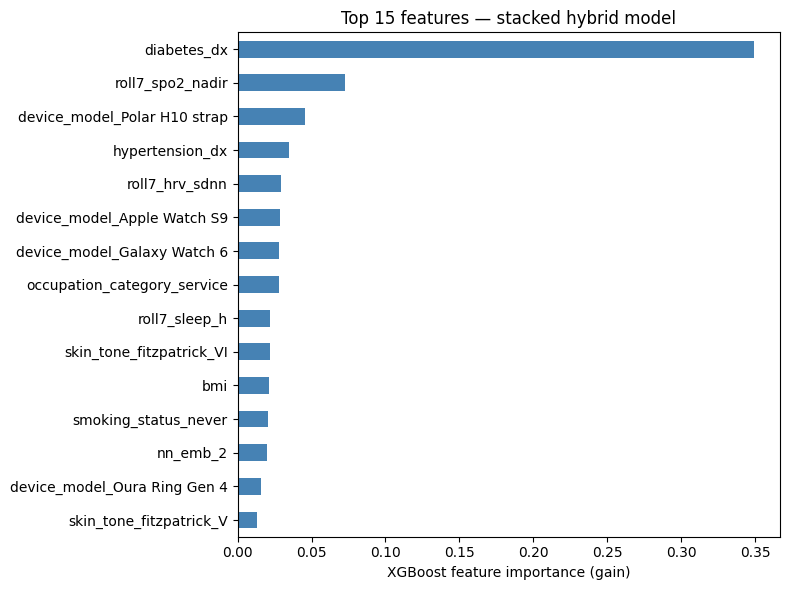

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
top15[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Top 15 features — stacked hybrid model")
plt.tight_layout()
plt.show()